In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.autograd import Variable

import cv2
import numpy as np
import time
from PIL import Image

from SAM.modeling.mask_decoder import MaskDecoder
from SAM.modeling.prompt_encoder import PromptEncoder
from SAM.modeling.transformer import TwoWayTransformer
from SAM.modeling.common import LayerNorm2d
from typing import List, Tuple, Type, Optional
# from SAM.modeling.student_encoder import SemiTViT

from torchmetrics.classification import BinaryAccuracy, BinaryJaccardIndex
from torchmetrics.classification import BinaryF1Score

from torch.optim import lr_scheduler

import os
from tqdm import tqdm
from collections import OrderedDict
# from functools import partial
# from timm.models import create_model

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
## DIY modules
from SAM.modules.modality_inspector import Modality_Inspector
from SAM.modules.normalized_bbox_regressor import NormalizedBBoxRegressor

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [35]:
device

device(type='cuda')

In [36]:
## load pretrained models
modality_inspector = Modality_Inspector(num_classes=6).to(device)
bbox_generator = NormalizedBBoxRegressor().to(device)

In [37]:
class ESPMedSAM(nn.Module):
    
    def __init__(self, modality_inspector = None, bbox_generator = None):
        
        super(ESPMedSAM, self).__init__()

        # self.SemiTViT = SemiTViT(img_size=1024, in_chans=3, num_classes=1000,
        #         embed_dims=[64, 128, 160, 320],
        #         depths=[2, 2, 6, 2],
        #         num_heads=[2, 4, 5, 10],
        #         window_sizes=[7, 7, 14, 7],
        #         mlp_ratio=4.,
        #         drop_rate=0.,
        #         drop_path_rate=0.0,
        #         use_checkpoint=False,
        #         mbconv_expand_ratio=4.0,
        #         local_conv_size=3,
        #         layer_lr_decay=0.8
        #     )

        self.modality_inspector = modality_inspector
        self.bbox_generator = bbox_generator

        self.prompt_encoder = PromptEncoder(
            embed_dim=256,
            image_embedding_size=(64, 64), # 1024 // 16
            input_image_size=(1024, 1024),
            mask_in_chans=16,
            )
        
        self.mask_decoder = MaskDecoder(
            transformer=TwoWayTransformer(
                depth=2,
                embedding_dim=256,
                mlp_dim=2048,
                num_heads=8,
            ),
            transformer_dim=256,
            )

        ## input h/2 w/2
        self.patch_decoder = nn.Sequential(nn.Conv2d(256, 64, kernel_size=2, stride=2),
            LayerNorm2d(64),
            nn.GELU(),
            nn.Conv2d(64, 1, kernel_size=1))
        
        self.dense_prompter = nn.Sequential(nn.Conv2d(1, 256, kernel_size=1),
            LayerNorm2d(256),
            nn.GELU())

        self.num_mask_tokens = 7
        self.mask_query = nn.Embedding(self.num_mask_tokens, 256)


    ## modified input as the mobileSAM image embedding
    def forward(self, image_embeddings, img_id=None):

        # b = x.shape[0]
        b = image_embeddings.shape[0]
        
        # image_embeddings = self.SemiTViT(x)
        bbox_output = self.bbox_generator(image_embeddings)
        # print("bbox_output output: ", bbox_output)

        modality_prob = self.modality_inspector(image_embeddings)
        _, domain_seq = torch.max(modality_prob.data, 1)
        # print("domain_seq output:", domain_seq)
        
        ## used for patch decoder training
        patch_map = self.patch_decoder(image_embeddings)
        
        ## 梯度在此截断(.detach()复制tensor, 截断梯度)
        prob_map = torch.sigmoid(patch_map.detach())
        prob_map[prob_map >= 0.5] = 1
        prob_map[prob_map < 0.5] = 0
        prob_map = F.interpolate(prob_map, scale_factor=2)
        
        patch_embeddings = self.dense_prompter(prob_map)
        
        outputs_mask = []

        for idx in range(b): # for each image in batch 

            image_embeddings_dec = image_embeddings[idx].unsqueeze(0)


            ###########
            ### 看起来对于没有 point box mask的情况下，这段代码没有用。
            ###########
            
            sparse_embeddings, dense_embeddings = self.prompt_encoder(
                points=None,
                boxes=None,
                masks=None,
            )

            image_pe = self.prompt_encoder.get_dense_pe()
            
            ############
            ###
            ############

            # Mask 
            mask_tokens = self.mask_query.weight
            mask_tokens = mask_tokens.unsqueeze(0).expand(sparse_embeddings.size(0), -1, -1)
            tokens_mask = torch.cat((mask_tokens, sparse_embeddings), dim=1) # 1 x 5 x 256

            # Expand per-image data in batch direction to be per-mask
            mask_src = torch.repeat_interleave(image_embeddings_dec, tokens_mask.shape[0], dim=0)
            mask_src = mask_src + patch_embeddings[idx].unsqueeze(0) # 1 x 256 x 64 x 64
            mask_pos_src = torch.repeat_interleave(image_pe, tokens_mask.shape[0], dim=0)  # 1 x 256 x 64 x 64

            low_res_masks = self.mask_decoder(
                src=mask_src,
                pos_src=mask_pos_src,
                tokens=tokens_mask,
                mcls=domain_seq[idx] #[idx]
            )

            masks = F.interpolate(low_res_masks, (1024, 1024), mode="bilinear", align_corners=False)
            outputs_mask.append(masks.squeeze(0))

        return torch.stack(outputs_mask, dim=0).squeeze(1), patch_map.squeeze(1), bbox_output, domain_seq

In [38]:
data_label_dic = {
    "CVC_ClinicDB" : 0, # Colonoscopy   - 612 img / 612 mask
    "Darwin": 1,       # X-ray         - 6106 img / 6106 mask
    "DRIVE": 2,         # Fundus        - 40 img / 40 mask
    "DSB_2018": 3,      # Microscopy    - 670 img / 670 mask
    "ISIC_2018": 4,     # Dermoscopy    - 3694 img / 3694 mask
    "Montgomery": 1,    # X-ray         - 138 img / 138 mask
    "PCXA": 1,          # X-ray         - 55 img / 55 mask
    "Shenzhen" : 1,     # X-ray         - 566 img / 566 mask
    "UDIAT" : 5         # Ultrasound    - 163 img / 163 mask
}

idx_name = {
    0: "Colonoscopy",
    1: "X-ray",
    2: "Fundus",
    3: "Microscopy",
    4: "Dermoscopy",
    5: "Ultrasound"
}

In [39]:
# 医疗图像数据集类
class Medcial_Dataset(Dataset):
    
    def __init__(self, files, labels, folder):
        self.folder = folder
        self.files = files
        self.labels = labels
        self.image_size = 1024
    
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        # image embedding loading
        image_embedding_path = os.path.join(self.folder, self.files[idx])
        image_embedding = torch.load(image_embedding_path)

        # image mask loading
        elems = self.files[idx].split("_set_file_")
        mask_path = f"../datasets/{elems[0]}/mask/{elems[1].split(".")[0]}.png"
        mask = Image.open(mask_path).convert('L')
        mask = np.array(mask)
        mask = cv2.resize(mask, (self.image_size, self.image_size), 
                             interpolation=cv2.INTER_NEAREST)
        mask[mask>0]=255
        mask = mask/255

        # image class output
        label = self.labels[idx]
        
        return image_embedding, mask, label, self.files[idx]

## Base SAM features

In [40]:
datafolder = "../SAM_mobile_features/image_feature"

files = os.listdir(datafolder)
labels = []
for f in files:
    labels.append(data_label_dic[f.split("_set_file_")[0]])

X_train, X_val, y_train, y_val = train_test_split(
    files, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [41]:
train_dataset = Medcial_Dataset(X_train, y_train, folder = datafolder)
val_dataset = Medcial_Dataset(X_val, y_val, folder = datafolder)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=10)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=10)

## 评测标准
iou_metric = BinaryJaccardIndex().to(device)
acc_metric = BinaryAccuracy(multidim_average='samplewise').to(device)

dataloaders = {
    "train": train_loader,
    "valid": val_loader
}

In [43]:
model = ESPMedSAM(modality_inspector = modality_inspector, bbox_generator = bbox_generator).to(device)

checkpoint = torch.load("combined_model_experiments/exp_20260708_143301/model_final_198.pth", map_location=device)
new_state_dict = OrderedDict()

for k, v in checkpoint.items():
    new_key = k.replace("module.", "")
    new_state_dict[new_key] = v

model.load_state_dict(new_state_dict)

<All keys matched successfully>

In [44]:
domain_accuracy = 0
iou_per_domain = {0:[], 1:[], 2:[], 3:[], 4:[], 5:[]}

_file_paths = []
_masks = []
_labels = []

model.eval()
with torch.no_grad():
    for data, target, labels, file_path in tqdm(dataloaders["valid"]):
        data = data.float().to(device)
        target = target.float().to(device)

        masks, patch_map, bbox_output, domain_pred = model(data)

        pred_mask = (torch.sigmoid(masks) > 0.5).int()

        _file_paths.append(file_path)
        _labels.append(labels)
        _masks.append(masks)
        

        # labels: (B,)
        for lbl in range(6):
            mask_idx = labels == lbl
            if mask_idx.sum() == 0:
                continue

            iou_val = iou_metric(
                pred_mask[mask_idx],
                target[mask_idx]
            )

            iou_per_domain[lbl].append(iou_val.item())

mean_iou_per_domain = {
    k: sum(v) / len(v) if v else None
    for k, v in iou_per_domain.items()
}

for k, v in mean_iou_per_domain.items():
    print(f"Domain {idx_name[k]} Mean IoU: {v}")

100%|███████████████████████████████████████████| 38/38 [00:27<00:00,  1.37it/s]

Domain Colonoscopy Mean IoU: 0.9098421931266785
Domain X-ray Mean IoU: 0.9513295277168876
Domain Fundus Mean IoU: 0.34961286932229996
Domain Microscopy Mean IoU: 0.8553637266159058
Domain Dermoscopy Mean IoU: 0.9449275935951033
Domain Ultrasound Mean IoU: 0.8788241821786632


In [45]:
concat_file_paths = []
for i in range(len(_file_paths)):
    for p in _file_paths[i]:
        concat_file_paths.append(p)

In [46]:
concat_label = np.concatenate([_labels[i].numpy() for i in range(len(_labels))])

In [47]:
concate_mask = np.concatenate([(torch.sigmoid(_masks[i]) > 0.5).int().cpu().numpy() for i in range(len(_masks))])

In [48]:
print(len(concat_file_paths))
print(len(concat_label))
print(len(concate_mask))

2373
2373
2373


In [49]:
from collections import defaultdict

label2idx = defaultdict(list)
for i, l in enumerate(concat_label):
    label2idx[l].append(i)

In [55]:
idx = []
for key, value in label2idx.items():
    print(key, value[:2])
    idx.extend(value[:2])

1 [0, 1]
4 [2, 3]
3 [23, 37]
0 [32, 48]
5 [131, 216]
2 [228, 1336]


In [56]:
concat_label[idx]

array([1, 1, 4, 4, 3, 3, 0, 0, 5, 5, 2, 2])

In [57]:
idx_name = {
    0: "Colonoscopy",
    1: "X-ray",
    2: "Fundus",
    3: "Microscopy",
    4: "Dermoscopy",
    5: "Ultrasound"
}

In [58]:
for i in idx:
    print(concat_file_paths[i])

Darwin_set_file_00003102_person382_bacteria_1739.pt
Darwin_set_file_00000628_person529_virus_1050.pt
ISIC_2018_set_file_ISIC_0014127.pt
ISIC_2018_set_file_ISIC_0023812.pt
DSB_2018_set_file_59.pt
DSB_2018_set_file_569.pt
CVC_ClinicDB_set_file_379.pt
CVC_ClinicDB_set_file_199.pt
UDIAT_set_file_000044.pt
UDIAT_set_file_000107.pt
DRIVE_set_file_29.pt
DRIVE_set_file_21.pt


'Darwin_set_file_00003102_person382_bacteria_1739.pt'

In [27]:
# idx = [0,1,2,9,4,5,22,58,60,216,2030,2142]
# for i in range(len(concat_file_paths)):
#     plt.imsave("../all_pred_mask/"+concat_file_paths[i].split("_set_file_")[-1][:-3] + ".png", concate_mask[i], cmap = "gray")

In [62]:
for i in idx:
    plt.imsave("combined_model_experiments/exp_20260708_143301/"+concat_file_paths[i][:-3] + ".png", concate_mask[i], cmap = "gray")

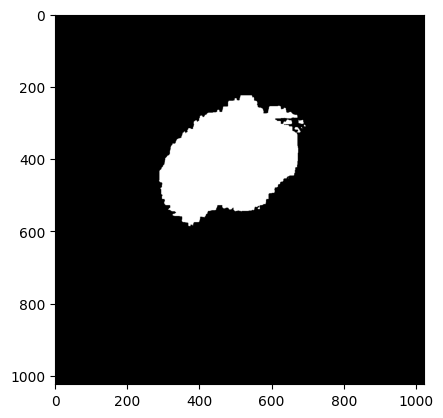

In [63]:
plt.imshow(concate_mask[2], cmap = "gray")

In [64]:
dice_per_domain = {0:[], 1:[], 2:[], 3:[], 4:[], 5:[]}
dice_metric = BinaryF1Score().to(device)
model.eval()
with torch.no_grad():
    for data, target, labels, _ in tqdm(dataloaders["valid"]):
        data = data.float().to(device)
        target = target.float().to(device)

        masks, _, _, _ = model(data)
        pred_mask = (torch.sigmoid(masks) > 0.5).int()

        for lbl in range(6):
            idx = labels == lbl
            if idx.sum() == 0:
                continue

            dice_val = dice_metric(
                pred_mask[idx],
                target[idx]
            )
            dice_per_domain[lbl].append(dice_val.item())

100%|███████████████████████████████████████████| 38/38 [00:24<00:00,  1.54it/s]


In [65]:
mean_dice_per_domain = {
    k: sum(v) / len(v) if v else None
    for k, v in dice_per_domain.items()
}

for k, v in mean_dice_per_domain.items():
    print(f"Domain {idx_name[k]} Mean Dice: {v:.4f}")

Domain Colonoscopy Mean Dice: 0.9520
Domain X-ray Mean Dice: 0.9751
Domain Fundus Mean Dice: 0.5175
Domain Microscopy Mean Dice: 0.9215
Domain Dermoscopy Mean Dice: 0.9716
Domain Ultrasound Mean Dice: 0.9347


In [ ]:
## S1: dice: 88.52    Dermoscopy
## S2: dice: 96.83    X-ray
## S3: dice: 82.42    Fundus
## S4: dice: 92.93    Colonoscopy
## S5: dice: 85.28    Ultrasound
## S6: dice: 92.24    Microscopy